In [1]:
from pgmpy.models import DiscreteBayesianNetwork
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
import pandas as pd
from itertools import product
import networkx as nx
import matplotlib.pyplot as plt
import pickle

In [2]:
def create_list(n_total: int, n: int):
    return [1] * n + [0] * (n_total - n)

In [3]:
def create_event_dict(n_total: int):
    default_list = [1] * n_total

    # If event names are same before '_'; they are considered mutually exclusive
    event_dict = {
        # 'cap2_1': {'prob': 0.06, 'factor': pd.DataFrame(data={('loc2', 'com1_process'): create_list(n_total, 13)})},
        # 'cap2_2': {'prob': 0.12, 'factor': pd.DataFrame(data={('loc2', 'com1_process'): create_list(n_total, 26)})},
        # 'cap2_3': {'prob': 0.17, 'factor': pd.DataFrame(data={('loc2', 'com1_process'): create_list(n_total, 39)})},
        # 'cap2_nd': {'prob': 0.65, 'factor': pd.DataFrame(data={('loc2', 'com1_process'): default_list})},

        # 'cap4_1': {'prob': 0.05, 'factor': pd.DataFrame(data={('loc4', 'com1_process'): create_list(n_total, 13)})},
        # 'cap4_2': {'prob': 0.15, 'factor': pd.DataFrame(data={('loc4', 'com1_process'): create_list(n_total, 26)})},
        # 'cap4_3': {'prob': 0.18, 'factor': pd.DataFrame(data={('loc4', 'com1_process'): create_list(n_total, 39)})},
        # 'cap4_nd': {'prob': 0.62, 'factor': pd.DataFrame(data={('loc4', 'com1_process'): default_list})},

        'cap7_1': {'prob': 0.04, 'factor': pd.DataFrame(data={('loc7', 'com1_process'): create_list(n_total, 13)})},
        'cap7_2': {'prob': 0.15, 'factor': pd.DataFrame(data={('loc7', 'com1_process'): create_list(n_total, 26)})},
        'cap7_3': {'prob': 0.2, 'factor': pd.DataFrame(data={('loc7', 'com1_process'): create_list(n_total, 39)})},
        'cap7_nd': {'prob': 0.61, 'factor': pd.DataFrame(data={('loc7', 'com1_process'): default_list})},

        # 'res1_1': {'prob': 0.06, 'factor': pd.DataFrame(data={('loc1', 'com1_pur'): create_list(n_total, 13)})},
        # 'res1_2': {'prob': 0.12, 'factor': pd.DataFrame(data={('loc1', 'com1_pur'): create_list(n_total, 26)})},
        # 'res1_3': {'prob': 0.19, 'factor': pd.DataFrame(data={('loc1', 'com1_pur'): create_list(n_total, 39)})},
        # 'res1_nd': {'prob': 0.63, 'factor': pd.DataFrame(data={('loc1', 'com1_pur'): default_list})},

        'res6_1': {'prob': 0.03, 'factor': pd.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total, 13)})},
        'res6_2': {'prob': 0.16, 'factor': pd.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total, 26)})},
        'res6_3': {'prob': 0.17, 'factor': pd.DataFrame(data={('loc6', 'com1_pur'): create_list(n_total, 39)})},
        'res6_nd': {'prob': 0.64, 'factor': pd.DataFrame(data={('loc6', 'com1_pur'): default_list})},

        # 'truck47_2': {'prob': 0.2, 'factor': pd.DataFrame(data={('truck47', 'com1_loc4_out'): create_list(n_total, 26)})},
        # 'truck47_nd': {'prob': 0.8, 'factor': pd.DataFrame(data={('truck47', 'com1_loc4_out'): default_list})},

        'truck25_1': {'prob': 0.3, 'factor': pd.DataFrame(data={('truck25', 'com1_loc2_out'): create_list(n_total, 13)})},
        'truck25_nd': {'prob': 0.7, 'factor': pd.DataFrame(data={('truck25', 'com1_loc2_out'): default_list})},
    }

    return event_dict

In [4]:
# Function to generate the scenario dictionary for n sets of events
def create_scenario_dict(event_dict):
    # Extract unique event prefixes (e.g., 'cap2', 'cap4', ...)
    event_prefixes = set(key.split('_')[0] for key in event_dict)

    # Group events by their prefixes
    grouped_events = {prefix: [key for key in event_dict if key.startswith(prefix)] for prefix in event_prefixes}

    # Create all possible combinations of events across the different groups
    event_combinations = list(product(*grouped_events.values()))

    scenario_dict = {}

    # Iterate over all event combinations
    for combination in event_combinations:
        # Construct the scenario key
        scenario_key = ' '.join(combination)

        # Calculate the probability of this scenario
        prob = 1
        combined_factor = None

        for event_key in combination:
            # Multiply probabilities
            prob *= event_dict[event_key]['prob']

            # Combine factors (assumes they are pandas DataFrames)
            if combined_factor is None:
                combined_factor = event_dict[event_key]['factor'].copy()
            else:
                combined_factor = combined_factor.add(event_dict[event_key]['factor'], fill_value=0)

        # Add to the scenario dictionary
        scenario_dict[scenario_key] = {'prob': prob, 'factor': combined_factor}

    return scenario_dict

In [5]:
def plot_bn_tree_with_probs(model):
    """
    Plots the Bayesian network structure and annotates each node
    with its marginal probabilities of all states.
    """
    # Perform inference to compute marginals
    infer = VariableElimination(model)
    
    marginals = {}
    for node in model.nodes():
        q = infer.query(variables=[node])
        state_names = q.state_names[node]
        probs = q.values
        # Format label like: "cap2\ncap2_1:0.06\ncap2_2:0.12..."
        label = f"{node}\n" + "\n".join(
            [f"{s.split('_')[-1]}: {p:.2f}" for s, p in zip(state_names, probs)]
        )
        marginals[node] = label

    # Draw structure
    G = nx.DiGraph(model.edges())
    pos = nx.spring_layout(G, seed=42)

    plt.figure(figsize=(8,6))
    nx.draw(
        G,
        pos,
        with_labels=False,
        node_size=3000,
        node_color="lightblue",
        edgecolors="black",
        arrowsize=20
    )

    # Draw labels with probabilities
    for node, (x, y) in pos.items():
        plt.text(
            x,
            y,
            marginals[node],
            ha='center',
            va='center',
            fontsize=9,
            bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", lw=0.8)
        )

    plt.title("Bayesian Scenario Structure with Node Probabilities", fontsize=12)
    plt.axis('off')
    plt.show()


In [6]:
# Define Bayesian structure
model = DiscreteBayesianNetwork([
    ('res6', 'truck25'),
    ('cap7', 'truck25'),
    ('res6', 'cap7')
])

In [7]:
cpd_res6 = TabularCPD(
    variable='res6',
    variable_card=4,
    values=[[0.03], [0.16], [0.17], [0.64]],
    state_names={'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd']}
)

In [8]:
# cpd_cap7 = TabularCPD(
#     variable='cap7',
#     variable_card=4,
#     values=[[0.04], [0.15], [0.2], [0.61]],
#     state_names={'cap7': ['cap7_1', 'cap7_2', 'cap7_3', 'cap7_nd']}
# )

In [9]:
# cap7 depends on res6
# 0.04, 0.15, 0.2, 0.61
cpd_cap7 = TabularCPD(
    variable='cap7',
    variable_card=4,
    values=[
        [0.06, 0.04, 0.04, 0.04],   # P(cap7_1 | res6_i)
        [0.2, 0.18, 0.15, 0.15],    # P(cap7_2 | res6_i)
        [0.25, 0.23, 0.22, 0.2],
        [0.49, 0.55, 0.59, 0.61]
    ],
    evidence=['res6'],
    evidence_card=[4],
    state_names={
        'cap7': ['cap7_1', 'cap7_2', 'cap7_3', 'cap7_nd'],
        'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd']
    }
)

In [10]:
cpd_truck25 = TabularCPD(
    variable='truck25',
    variable_card=2,
    values=[
        # P(truck25_1 | each (res6,cap7) combination)
        [0.7, 0.3, 0.3, 0.3,  0.5, 0.3, 0.3, 0.3,  0.5, 0.3, 0.3, 0.3,  0.5, 0.3, 0.3, 0.3],
        # P(truck45_nd | ...) = 1 - above
        [0.3, 0.7, 0.7, 0.7,  0.5, 0.7, 0.7, 0.7,  0.5, 0.7, 0.7, 0.7,  0.5, 0.7, 0.7, 0.7],
    ],
    evidence=['res6', 'cap7'],
    evidence_card=[4, 4],
    state_names={
        'truck25': ['truck25_1', 'truck25_nd'],
        'res6': ['res6_1', 'res6_2', 'res6_3', 'res6_nd'],
        'cap7': ['cap7_1', 'cap7_2', 'cap7_3', 'cap7_nd'],
    }
)

In [11]:
model.add_cpds(cpd_cap7, cpd_truck25, cpd_res6)

In [12]:
assert model.check_model()

In [13]:
inference = VariableElimination(model)

In [14]:
joint = inference.query(variables=['cap7', 'res6', 'truck25'], joint=True)

In [15]:
joint_values = joint.values.flatten()
joint_states = joint.state_names

In [16]:
def build_scenario_dict_from_bn(joint, event_dict):
    scenario_dict = {}
    state_names = list(joint.state_names.keys())
    all_states = product(*joint.state_names.values())

    for idx, states in enumerate(all_states):
        scenario_key = ' '.join(states)
        prob = joint.values.flatten()[idx]

        # Combine relevant factors
        combined_factor = None
        for s in states:
            if s in event_dict:
                f = event_dict[s]['factor']
                combined_factor = f.copy() if combined_factor is None else combined_factor.add(f, fill_value=0)

        scenario_dict[scenario_key] = {'prob': prob, 'factor': combined_factor}

    return scenario_dict


In [17]:
event_dict = create_event_dict(52)
bayesian_scenario_dict = build_scenario_dict_from_bn(joint, event_dict)

In [18]:
scenario_dict = create_scenario_dict(event_dict=event_dict)

In [19]:
len(list(bayesian_scenario_dict.keys()))

32

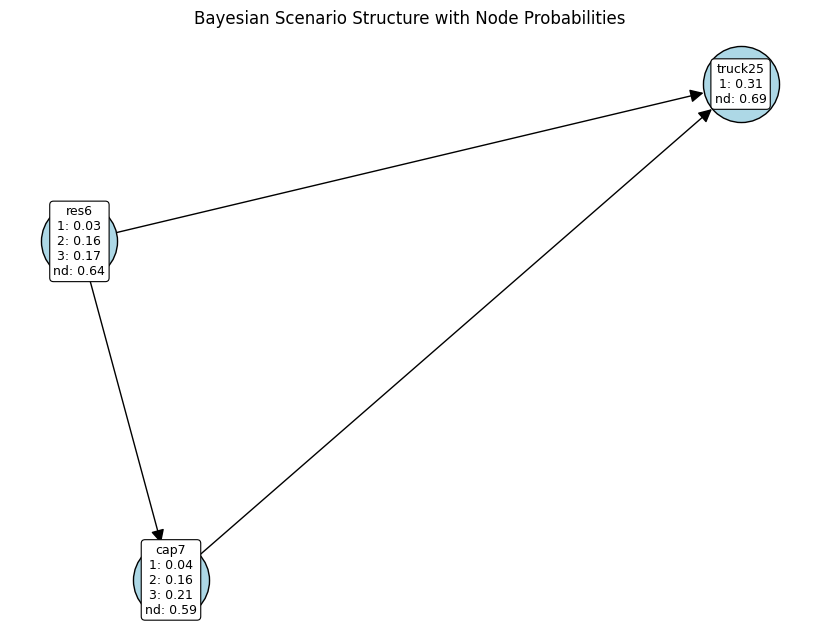

In [20]:
plot_bn_tree_with_probs(model)

In [21]:
for k, v in bayesian_scenario_dict.items():
    print(k, v['prob'])

cap7_1 res6_1 truck25_1 0.0012599999999999998
cap7_1 res6_1 truck25_nd 0.00054
cap7_1 res6_2 truck25_1 0.0032
cap7_1 res6_2 truck25_nd 0.0032
cap7_1 res6_3 truck25_1 0.0034000000000000002
cap7_1 res6_3 truck25_nd 0.0034000000000000002
cap7_1 res6_nd truck25_1 0.0128
cap7_1 res6_nd truck25_nd 0.0128
cap7_2 res6_1 truck25_1 0.0018
cap7_2 res6_1 truck25_nd 0.0042
cap7_2 res6_2 truck25_1 0.00864
cap7_2 res6_2 truck25_nd 0.020159999999999997
cap7_2 res6_3 truck25_1 0.0076500000000000005
cap7_2 res6_3 truck25_nd 0.01785
cap7_2 res6_nd truck25_1 0.0288
cap7_2 res6_nd truck25_nd 0.0672
cap7_3 res6_1 truck25_1 0.00225
cap7_3 res6_1 truck25_nd 0.0052499999999999995
cap7_3 res6_2 truck25_1 0.01104
cap7_3 res6_2 truck25_nd 0.025759999999999998
cap7_3 res6_3 truck25_1 0.01122
cap7_3 res6_3 truck25_nd 0.026180000000000002
cap7_3 res6_nd truck25_1 0.0384
cap7_3 res6_nd truck25_nd 0.0896
cap7_nd res6_1 truck25_1 0.00441
cap7_nd res6_1 truck25_nd 0.010289999999999999
cap7_nd res6_2 truck25_1 0.02640000

In [22]:
for k, v in scenario_dict.items():
    print(k, v['prob'])

res6_1 truck25_1 cap7_1 0.00035999999999999997
res6_1 truck25_1 cap7_2 0.0013499999999999999
res6_1 truck25_1 cap7_3 0.0018
res6_1 truck25_1 cap7_nd 0.005489999999999999
res6_1 truck25_nd cap7_1 0.0008399999999999999
res6_1 truck25_nd cap7_2 0.0031499999999999996
res6_1 truck25_nd cap7_3 0.0042
res6_1 truck25_nd cap7_nd 0.012809999999999998
res6_2 truck25_1 cap7_1 0.00192
res6_2 truck25_1 cap7_2 0.0072
res6_2 truck25_1 cap7_3 0.009600000000000001
res6_2 truck25_1 cap7_nd 0.02928
res6_2 truck25_nd cap7_1 0.00448
res6_2 truck25_nd cap7_2 0.0168
res6_2 truck25_nd cap7_3 0.0224
res6_2 truck25_nd cap7_nd 0.06831999999999999
res6_3 truck25_1 cap7_1 0.00204
res6_3 truck25_1 cap7_2 0.0076500000000000005
res6_3 truck25_1 cap7_3 0.0102
res6_3 truck25_1 cap7_nd 0.031110000000000002
res6_3 truck25_nd cap7_1 0.0047599999999999995
res6_3 truck25_nd cap7_2 0.017849999999999998
res6_3 truck25_nd cap7_3 0.0238
res6_3 truck25_nd cap7_nd 0.07259
res6_nd truck25_1 cap7_1 0.00768
res6_nd truck25_1 cap7_2 0

In [23]:
# with open('backlog_bayesian_scen_dict_ncl.pkl', 'wb') as file:
#     pickle.dump(bayesian_scenario_dict, file)
# 
# # print(*scenario_names, sep='\n')
# print(f"Sum of probabilities of all scenarios: {sum(bayesian_scenario_dict[scen]['prob'] for scen in bayesian_scenario_dict):.6f}")
# print(f'Number of considered scenarios: {len(bayesian_scenario_dict.keys())}')

In [24]:
with open('backlog_bayesian_scen_dict_ncl.pkl', 'rb') as file:
    load_bayesian_scenario_dict_ncl = pickle.load(file)

# print(*scenario_names, sep='\n')
print(f"Sum of probabilities of all scenarios: {sum(load_bayesian_scenario_dict_ncl[scen]['prob'] for scen in bayesian_scenario_dict):.6f}")
print(f'Number of considered scenarios: {len(load_bayesian_scenario_dict_ncl.keys())}')

Sum of probabilities of all scenarios: 1.000000
Number of considered scenarios: 32
